In [1]:
print('hi')

hi


In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

# os.getenv("GROQ_API_KEY")

True

In [3]:
model="openai/gpt-oss-120b"

In [4]:
from langchain_groq import ChatGroq

In [5]:
llm=ChatGroq(model=model, api_key=os.getenv("GROQ_API_KEY"))

In [6]:
llm.invoke('hi')

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says "hi". We just need to respond politely. Probably greet back, ask how can help.'}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 72, 'total_tokens': 113, 'completion_time': 0.085749882, 'completion_tokens_details': {'reasoning_tokens': 23}, 'prompt_time': 0.011354533, 'prompt_tokens_details': None, 'queue_time': 0.211187425, 'total_time': 0.097104415}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_ca17e3cea8', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d9fa1-b0e7-7a72-ab9b-41812e9af6d9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 41, 'total_tokens': 113, 'output_token_details': {'reasoning': 23}})

### Designing workflow for ReAct Agent

In [7]:
from pydantic import BaseModel, Field
from typing import Annotated, Sequence, TypedDict
from langchain_core.messages import BaseMessage, AIMessage
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
import operator
from typing import List, TypedDict, Annotated, Sequence
from langgraph.graph.message import add_messages
from IPython.display import Image, display
from langchain_core.messages import HumanMessage
from langchain.tools import tool
from langgraph.prebuilt import ToolNode


langgraph provides a built-in state, i.e; MessageState. Can either build custom state or use the built-in one as well

In [8]:
def call_model(state: MessagesState):
    messages = state['messages']
    response = llm.invoke(messages)
    return {"messages": [response]}

In [9]:
state={'messages':['hi, how are you?']}

In [10]:
call_model(state)

{'messages': [AIMessage(content="Hey there! I'm doing great, thanks for asking. How can I help you today?", additional_kwargs={'reasoning_content': 'We need to respond. The system says we are ChatGPT, no special instruction beyond normal. The user says hi, how are you? We should respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 77, 'total_tokens': 138, 'completion_time': 0.131137809, 'completion_tokens_details': {'reasoning_tokens': 34}, 'prompt_time': 0.00381167, 'prompt_tokens_details': None, 'queue_time': 0.050576099, 'total_time': 0.134949479}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e10890e4b9', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d9fa1-b2ff-7933-8957-1ddb9acbace7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_tokens': 61, 'total_tokens': 138, 'output_token_details': {'reasoning': 34}})]}

### WORKFLOW CREATION

In [11]:
workflow=StateGraph(MessagesState)

In [12]:
workflow.add_node('MyBot', call_model)

In [13]:
workflow.add_edge(START, 'MyBot')

In [14]:
workflow.add_edge('MyBot', END)

In [15]:
app=workflow.compile()

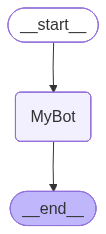

In [16]:
display(Image(app.get_graph().draw_mermaid_png()))

In [17]:
app.invoke({'messages':['hi, how are you?']})

{'messages': [HumanMessage(content='hi, how are you?', additional_kwargs={}, response_metadata={}, id='2bbc6de7-db80-41a5-8b77-1ddd263a0dc3'),
  AIMessage(content="Hello! I'm doing great, thank you for asking. How can I assist you today?", additional_kwargs={'reasoning_content': 'The user says "hi, how are you?" It\'s a simple greeting. We respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 77, 'total_tokens': 124, 'completion_time': 0.099493335, 'completion_tokens_details': {'reasoning_tokens': 20}, 'prompt_time': 0.003471213, 'prompt_tokens_details': None, 'queue_time': 0.050389436, 'total_time': 0.102964548}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_626f3fc5e0', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d9fa1-b525-77b0-933e-435eb61ae25d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_tokens': 47, 'total_toke

In [18]:
for output in app.stream(state):
    for key, value in output.items():
        print(f'Output from {key} node')
        print('________')
        print(value)

Output from MyBot node
________
{'messages': [AIMessage(content="Hello! I'm doing great, thank you for asking. How can I assist you today?", additional_kwargs={'reasoning_content': 'We need to respond. No policy issues. Just friendly.'}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 77, 'total_tokens': 117, 'completion_time': 0.084685357, 'completion_tokens_details': {'reasoning_tokens': 13}, 'prompt_time': 0.003829466, 'prompt_tokens_details': None, 'queue_time': 0.050528739, 'total_time': 0.088514823}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_d81b3304b3', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d9fa1-b5ee-7c91-a79c-0e4325dfc3a3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_tokens': 40, 'total_tokens': 117, 'output_token_details': {'reasoning': 13}})]}


#### Custom Tool

In [19]:
@tool
def search(query: str):
    """"Custom tool to Search the web for the weather query"""
    if "delhi" in query.lower():
        return "The temp is 45 degree and sunny"
    return "The temp. is 25 degree and cloudy"

In [20]:
search.invoke("what is the temp in Kashmir?")

'The temp. is 25 degree and cloudy'

In [21]:
search.invoke("what is the temp in Delhi?")

'The temp is 45 degree and sunny'

#### Binding tool with LLM
Special Note: Use some good model for Agentic Workflow since Open Source Models might not give the correct output as they might not be good in reasoning


In [22]:
search

StructuredTool(name='search', description='"Custom tool to Search the web for the weather query', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x12c8c1800>)

In [23]:
tools=[search]

In [24]:
llm_with_tool=llm.bind_tools(tools)

In [25]:
response=llm_with_tool.invoke("what is the weather in Delhi?")

## getting blank answer bcoz by default its redirecting the question to the tool call
## LLM based on its intelligence, redirects the query to the tool call

In [26]:
response

AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks "what is the weather in Delhi?" We need to fetch current weather. Use the provided search tool. Probably query "Delhi weather". Use function.', 'tool_calls': [{'id': 'fc_e3268fc6-cd5d-4ba2-a6bf-f73aae9d0c7c', 'function': {'arguments': '{"query":"Delhi weather"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 131, 'total_tokens': 192, 'completion_time': 0.133506413, 'completion_tokens_details': {'reasoning_tokens': 34}, 'prompt_time': 0.007232007, 'prompt_tokens_details': None, 'queue_time': 0.051807613, 'total_time': 0.14073842}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_d81b3304b3', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d9fa1-c476-7da1-87a0-ae1ebd6af516-0', tool_calls=[{'name': 'search', 'args': {'query': 'Delhi weather'}, 'id': 'fc_e32

In [27]:
response.tool_calls

## after binding multiple tools with the llm, the llm redirects the query to appropriate tool based on its intelligence.

[{'name': 'search',
  'args': {'query': 'Delhi weather'},
  'id': 'fc_e3268fc6-cd5d-4ba2-a6bf-f73aae9d0c7c',
  'type': 'tool_call'}]

In [28]:
def call_model(state: MessagesState):
    question=state['messages']
    response=llm_with_tool.invoke(question)
    return {"messages": [response]}

In [29]:
text_input={'messages':['whats the weather in Delhi?']}

In [30]:
response=call_model(text_input)

In [31]:
response["messages"][-1].content

''

In [32]:
response['messages'][-1].tool_calls

[{'name': 'search',
  'args': {'query': 'current weather Delhi'},
  'id': 'fc_4818b7c5-18d5-441d-a47c-af0c69db9d28',
  'type': 'tool_call'}]

In [33]:
def router_function(state:MessagesState):
    message=state["messages"]
    last_message=message[-1]
    if last_message.tool_calls:
        return "tools"
    return END

In [34]:
workflow2=StateGraph(MessagesState)

In [35]:

workflow2.add_node('llmwithtool', call_model)

In [36]:
tool_node=ToolNode(tools)

In [37]:
workflow2.add_node('mytools', tool_node)

In [38]:
workflow2.add_edge(START, "llmwithtool")

In [39]:
workflow2.add_conditional_edges(
    "llmwithtool",
    router_function,
    {
        "tools": "mytools",
        END: END,
    },
)



In [40]:
app2=workflow2.compile()

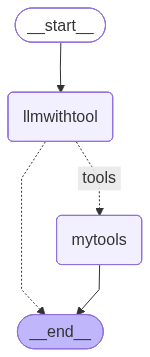

In [41]:
display(Image(app2.get_graph().draw_mermaid_png()))

In [46]:
app2.invoke({"messages":["whats the weather in Delhi?"]})

{'messages': [HumanMessage(content='whats the weather in Delhi?', additional_kwargs={}, response_metadata={}, id='4c8a32cf-4889-4328-8dcb-9b5c4139c2a7'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks: "whats the weather in Delhi?" We need current weather. Use web search tool.', 'tool_calls': [{'id': 'fc_12ec8610-baf0-4980-98a1-9df487afc797', 'function': {'arguments': '{"query":"current weather Delhi"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 131, 'total_tokens': 181, 'completion_time': 0.106782336, 'completion_tokens_details': {'reasoning_tokens': 22}, 'prompt_time': 0.0054843, 'prompt_tokens_details': None, 'queue_time': 0.0508168, 'total_time': 0.112266636}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_a09bde29de', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019da468-7ab0-7d61-b214-be035

In [47]:
response = app2.invoke({"messages":["whats the weather in Bengaluru?"]})

In [48]:
print(response['messages'][-1])
print('\n')
print(response['messages'][-1].content)

content='The temp. is 25 degree and cloudy' name='search' id='5884d19c-0b5e-41d8-9451-e63c520d01dd' tool_call_id='fc_9bb82728-89aa-41be-a691-69a40844059d'


The temp. is 25 degree and cloudy


In [49]:
app2.invoke({"messages":["Hi, how are you?"]})

{'messages': [HumanMessage(content='Hi, how are you?', additional_kwargs={}, response_metadata={}, id='1d3e28a0-4d2c-4062-acb0-b55937de3517'),
  AIMessage(content="Hello! I'm doing great, thank you for asking. How can I help you today?", additional_kwargs={'reasoning_content': 'We need to respond. The user says "Hi, how are you?" It\'s a casual greeting. We can respond politely. No tool needed.'}, response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 130, 'total_tokens': 187, 'completion_time': 0.117785482, 'completion_tokens_details': {'reasoning_tokens': 30}, 'prompt_time': 0.00629355, 'prompt_tokens_details': None, 'queue_time': 0.051477139, 'total_time': 0.124079032}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_a09bde29de', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019da4c1-cf43-7912-a33f-0575f4d827f5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens'

#### ReAct Agent

There will be a loop, loop represents the reasoning and action. First thinking and then action, then Reasoning again and then observation and then Action again and so on until a correct response comes.

In [50]:
workflow2.add_edge("mytools", "llmwithtool")

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [51]:
app3=workflow2.compile()

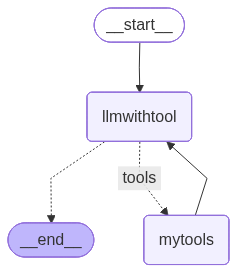

In [52]:
display(Image(app3.get_graph().draw_mermaid_png()))

In [55]:
for output3 in app3.stream({'messages':['whats the weather in Delhi?']}):
    for key, value in output3.items():
        print(f'Output from {key} node')
        print('________')
        print(value)
        print('\n')

Output from llmwithtool node
________
{'messages': [AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks "whats the weather in Delhi?" We need to get current weather. Use the provided search tool. Probably query "current weather Delhi". Let\'s use tool.', 'tool_calls': [{'id': 'fc_d3ca7e98-4f4a-4d86-8f0c-a55658bbb1dd', 'function': {'arguments': '{"query":"current weather Delhi"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 131, 'total_tokens': 195, 'completion_time': 0.137991192, 'completion_tokens_details': {'reasoning_tokens': 36}, 'prompt_time': 0.006051832, 'prompt_tokens_details': None, 'queue_time': 0.050873098, 'total_time': 0.144043024}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_a09bde29de', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019da4cc-c64d-7a73-9e81-6e7e19a22dae-0', tool_calls=[

#### Memory in LangGraph

In [56]:
from langgraph.checkpoint.memory import MemorySaver

In [58]:
memory=MemorySaver()

In [ ]:
for output4 in app3.stream({'messages':['whats the weather in Delhi, Can you tell me some good hotel for staying in North Delhi?']}):

In [59]:
workflow3=StateGraph(MessagesState)
workflow3.add_node('llmwithtool', call_model)
workflow3.add_node('mytools', tool_node)
workflow3.add_edge(START, "llmwithtool")
workflow3.add_conditional_edges(
    "llmwithtool",
    router_function,
    {'tools': 'mytools',
    END: END}) 
workflow3.add_edge("mytools", "llmwithtool")

In [60]:
app4=workflow3.compile(checkpointer=memory)

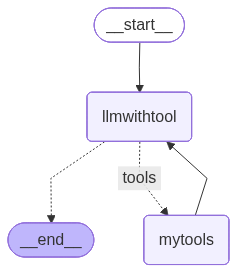

In [61]:
display(Image(app4.get_graph().draw_mermaid_png()))

In [62]:
config={"configurable":{"thread_id":"1"}}

In [64]:
events=app4.stream({'messages':['whats the weather in Delhi?']}, config=config, stream_mode="values")

In [ ]:
## the above configuration will be passed when streaming the output
# HOW STREAMING WORKS? -->
## Loading entire o/p in memory and in batches it going to process that. it loads the o/p in queue and one by one it pops out.
## If want answer in single shot --> use invoke on app
##  Otherwise call stream method

for event in events:
    event['messages'][-1].pretty_print()
# for output5 in app4.stream({'messages':['whats the weather in Delhi?']}, config=config, stream_mode="values"):
#     for key, value in output5.items():
#         print(f'Output from {key} node')
#         print('________')
#         print(value)
#         print('\n')

================================ Human Message =================================

whats the weather in Delhi?
================================== Ai Message ==================================
Tool Calls:
  search (fc_3caa088b-dcba-4c2d-bf06-237dda1cfbf5)
 Call ID: fc_3caa088b-dcba-4c2d-bf06-237dda1cfbf5
  Args:
    query: current weather Delhi
================================= Tool Message =================================
Name: search

The temp is 45 degree and sunny
================================== Ai Message ==================================

Sure! Here’s the latest snapshot for Delhi:

- **Temperature:** ≈ 45 °C (113 °F)  
- **Condition:** Sunny, clear skies  
- **Humidity:** Typically around 30‑40 % in this heat (exact figure not available in the quick check)  
- **Wind:** Light to moderate, generally from the west‑northwest  
- **Air Quality:** Often moderate to unhealthy during peak summer; consider checking a dedicated AQI service if you’ll be outdoors for long periods.

If y

In [66]:
events=app4.stream({'messages':['whats the weather in Indore?']}, config=config, stream_mode="values")

In [ ]:
for event in events:
    event['messages'][-1].pretty_print()

================================ Human Message =================================

whats the weather in Indore?
================================== Ai Message ==================================
Tool Calls:
  search (fc_f10691b8-a344-4f0e-99a3-8a46d89b29d3)
 Call ID: fc_f10691b8-a344-4f0e-99a3-8a46d89b29d3
  Args:
    query: Indore weather
================================= Tool Message =================================
Name: search

The temp. is 25 degree and cloudy
================================== Ai Message ==================================

Here’s the current weather for **Indore**:

- **Temperature:** ≈ 25 °C (77 °F)  
- **Condition:** Cloudy (overcast skies)  
- **Humidity:** Typically in the 50‑70 % range during this time of year (exact figure not in the quick check)  
- **Wind:** Light to moderate, generally from the southwest  

If you’d like a short‑term forecast, details on precipitation chances, or any other specifics, just let me know!


In [69]:
config

{'configurable': {'thread_id': '1'}}

In [ ]:
memory.get(config)

{'v': 4,
 'ts': '2026-04-19T08:28:09.583961+00:00',
 'id': '1f13bc9b-2960-6dfc-800d-5f89305cb77b',
 'channel_versions': {'__start__': '00000000000000000000000000000012.0.9602319169133636',
  'messages': '00000000000000000000000000000015.0.8636488951372095',
  'branch:to:llmwithtool': '00000000000000000000000000000015.0.8636488951372095',
  'branch:to:mytools': '00000000000000000000000000000014.0.8925830524176274'},
 'versions_seen': {'__input__': {},
  '__start__': {'__start__': '00000000000000000000000000000011.0.8147136681271977'},
  'llmwithtool': {'branch:to:llmwithtool': '00000000000000000000000000000014.0.8925830524176274'},
  'mytools': {'branch:to:mytools': '00000000000000000000000000000013.0.5789210023624075'}},
 'updated_channels': ['messages'],
 'channel_values': {'messages': [HumanMessage(content='whats the weather in Delhi?', additional_kwargs={}, response_metadata={}, id='0d9a62ec-8480-4876-aceb-daefae9b8517'),
   AIMessage(content='', additional_kwargs={'reasoning_conten

In [71]:
events=app4.stream({'messages':['In which city the temperature was 25 degrees?']}, config=config, stream_mode="values")

In [72]:
for event in events:
    event['messages'][-1].pretty_print()


================================ Human Message =================================

In which city the temperature was 25 degrees?
================================== Ai Message ==================================

The temperature of **25 °C** was reported for **Indore**. (Delhi’s temperature was reported as about 45 °C.)


In [73]:
memory.get(config)

{'v': 4,
 'ts': '2026-04-19T08:36:58.813961+00:00',
 'id': '1f13bcae-e082-64aa-8010-a0a326e7a5d9',
 'channel_versions': {'__start__': '00000000000000000000000000000017.0.4624076779496148',
  'messages': '00000000000000000000000000000018.0.13888808570305322',
  'branch:to:llmwithtool': '00000000000000000000000000000018.0.13888808570305322',
  'branch:to:mytools': '00000000000000000000000000000014.0.8925830524176274'},
 'versions_seen': {'__input__': {},
  '__start__': {'__start__': '00000000000000000000000000000016.0.18780205514175674'},
  'llmwithtool': {'branch:to:llmwithtool': '00000000000000000000000000000017.0.4624076779496148'},
  'mytools': {'branch:to:mytools': '00000000000000000000000000000013.0.5789210023624075'}},
 'updated_channels': ['messages'],
 'channel_values': {'messages': [HumanMessage(content='whats the weather in Delhi?', additional_kwargs={}, response_metadata={}, id='0d9a62ec-8480-4876-aceb-daefae9b8517'),
   AIMessage(content='', additional_kwargs={'reasoning_con